In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)



In [6]:
df = pd.read_parquet("../data/processed/dataset_dev.parquet")

df.sample(5)

,observed_at,stop_id,stop_name,line_id,direction,platform_name,destination_name,hour,weekday,is_weekend,time_to_station,roll_mean_tts_10m,roll_max_tts_10m,roll_count_10m,roll_std_tts_10m,baseline_median_tts,deviation_from_baseline,late
229461,2026-02-28 15:13:11.253297+00:00,940GZZLUEUS,Euston Underground Station,victoria,outbound,Northbound - Platform 4,Walthamstow Central Underground Station,15,5,1,760,468.757925,943.0,347.0,None,498.0,262.0,0
549176,2026-02-28 11:21:34.107321+00:00,940GZZLUSTD,Stratford Underground Station,jubilee,unknown,Westbound - Platform 15,Stratford Underground Station,11,5,1,150,917.678906,1809.0,1280.0,None,940.0,-790.0,0
461060,2026-02-28 13:34:55.441953+00:00,940GZZLUOXC,Oxford Circus Underground Station,victoria,outbound,Northbound - Platform 6,Walthamstow Central Underground Station,13,5,1,272,354.825000,703.0,240.0,None,399.0,-127.0,0
37685,2026-02-28 14:51:15.779210+00:00,940GZZLUBMY,Bermondsey Underground Station,jubilee,outbound,Eastbound - Platform 2,Stratford Underground Station,14,5,1,609,803.734694,1783.0,441.0,None,820.0,-211.0,0
455652,2026-02-28 15:05:45.664411+00:00,940GZZLUOXC,Oxford Circus Underground Station,victoria,inbound,Southbound - Platform 5,Brixton Underground Station,15,5,1,1002,578.559036,1115.0,415.0,None,540.0,462.0,1


In [7]:
df.shape

(910564, 18)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 910564 entries, 0 to 910563
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype              
---  ------                   --------------   -----              
 0   observed_at              910564 non-null  datetime64[us, UTC]
 1   stop_id                  910564 non-null  str                
 2   stop_name                910564 non-null  str                
 3   line_id                  910564 non-null  str                
 4   direction                910564 non-null  str                
 5   platform_name            910564 non-null  str                
 6   destination_name         910425 non-null  str                
 7   hour                     910564 non-null  int32              
 8   weekday                  910564 non-null  int32              
 9   is_weekend               910564 non-null  int64              
 10  time_to_station          910564 non-null  int64              
 11  roll_mean_tts_10m       

In [ ]:
# Time Coverage
df["observed_at"].min(), df["observed_at"].max()

(Timestamp('2026-02-28 10:14:02.269883+0000', tz='UTC'),
 Timestamp('2026-02-28 15:28:52.411725+0000', tz='UTC'))

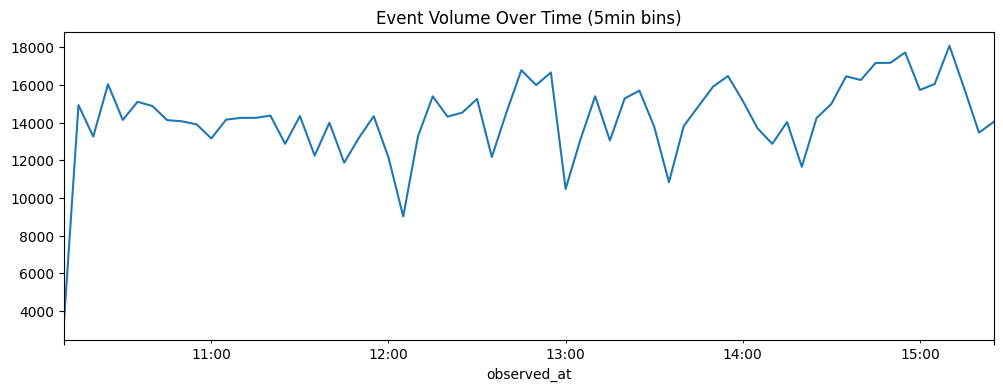

In [ ]:
# Event Volume Over Time
df.set_index("observed_at").resample("5min").size().plot(figsize=(12,4))
plt.title("Event Volume Over Time (5min bins)")
plt.show()

In [ ]:
# Target Distribution or Class balance
df["late"].value_counts(normalize=True)

late
0    0.724129
1    0.275871
Name: proportion, dtype: float64

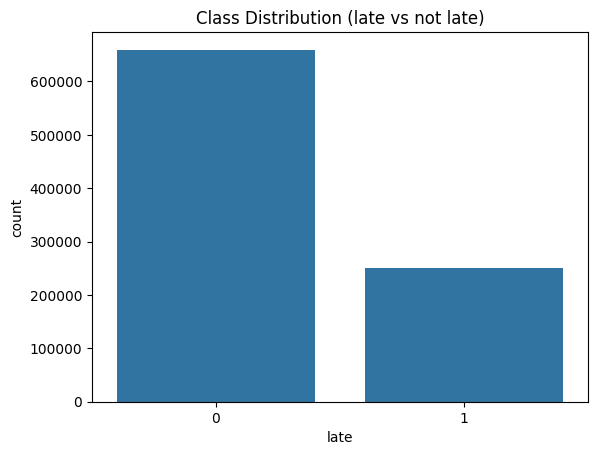

In [ ]:
# Class Distribution Plot
sns.countplot(x="late", data=df)
plt.title("Class Distribution (late vs not late)")
plt.show()

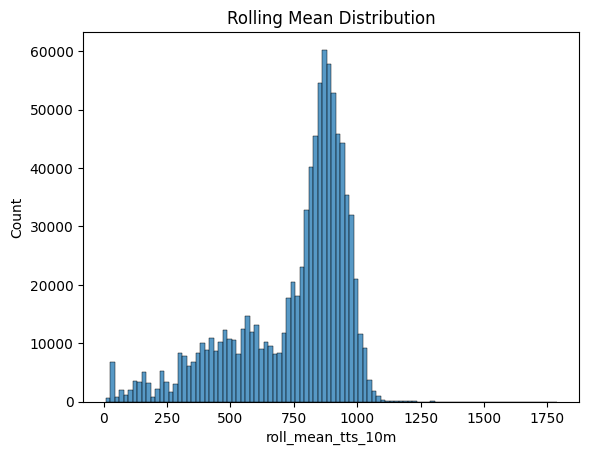

In [ ]:
# Rolling Mean Distribution
sns.histplot(df["roll_mean_tts_10m"], bins=100)
plt.title("Rolling Mean Distribution")
plt.show()

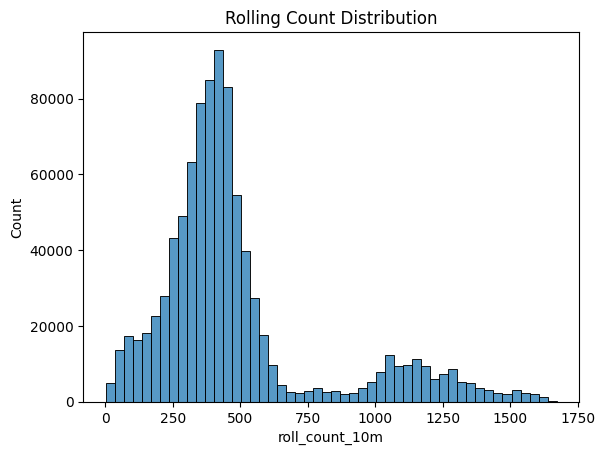

In [ ]:
# Rolling Count Distribution
sns.histplot(df["roll_count_10m"], bins=50)
plt.title("Rolling Count Distribution")
plt.show()

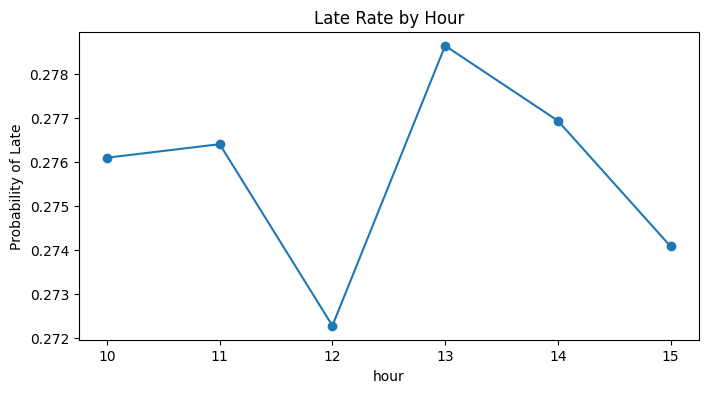

In [15]:
# Time-of-Day Effect
late_by_hour = df.groupby("hour")["late"].mean()

late_by_hour.plot(marker="o", figsize=(8,4))
plt.title("Late Rate by Hour")
plt.ylabel("Probability of Late")
plt.show()

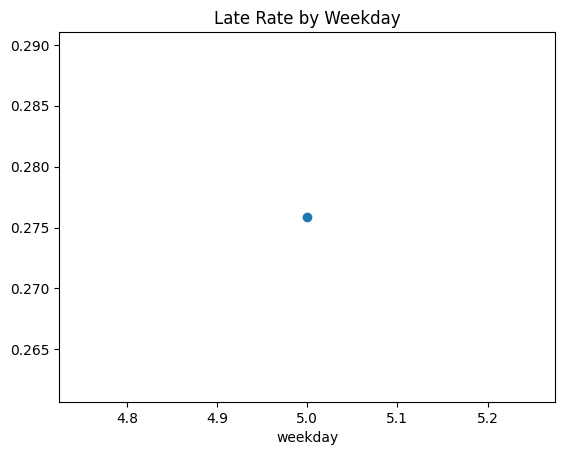

In [16]:
# Weekday Effect
late_by_weekday = df.groupby("weekday")["late"].mean()
late_by_weekday.plot(marker="o")
plt.title("Late Rate by Weekday")
plt.show()

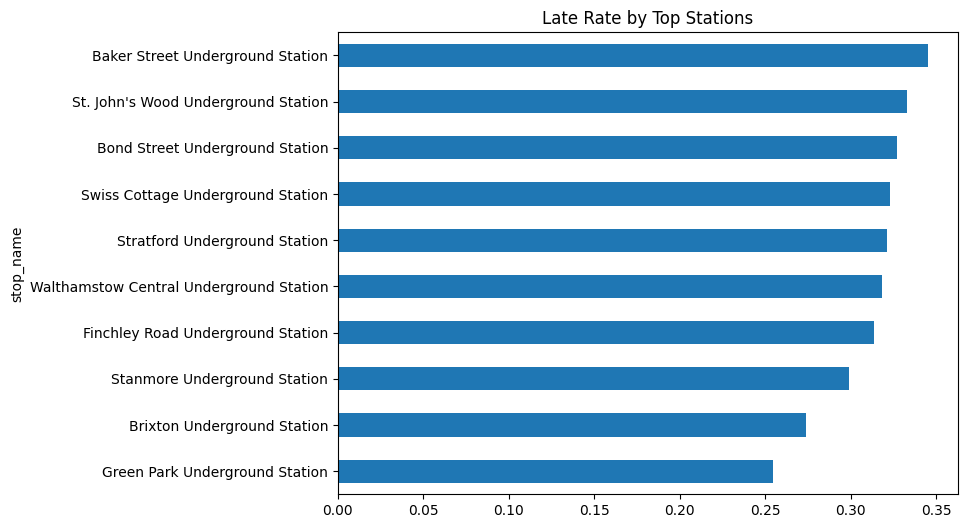

In [17]:
# Station-Level Variation
top_stations = df["stop_name"].value_counts().head(10).index

station_late = df[df["stop_name"].isin(top_stations)] \
    .groupby("stop_name")["late"].mean() \
    .sort_values()

station_late.plot(kind="barh", figsize=(8,6))
plt.title("Late Rate by Top Stations")
plt.show()

Correlation Matrix (without deviation)

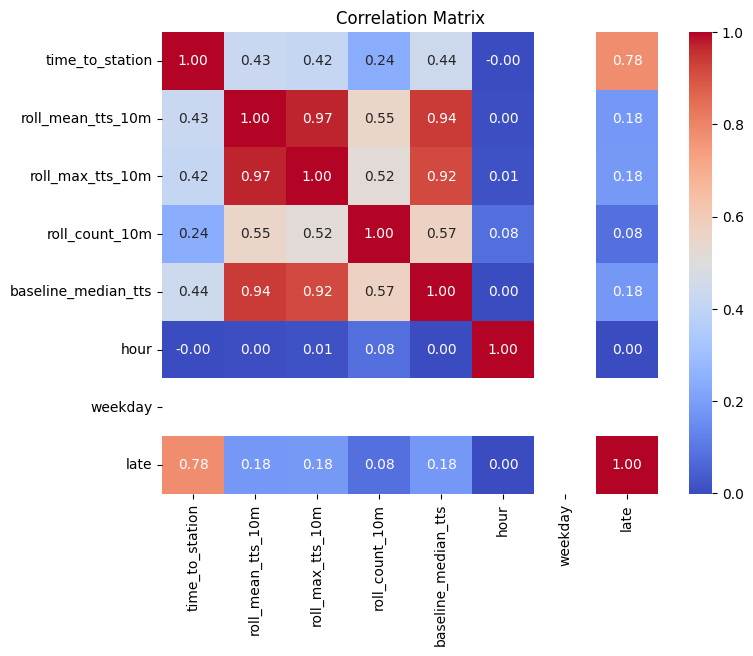

In [18]:
num_cols = [
    "time_to_station",
    "roll_mean_tts_10m",
    "roll_max_tts_10m",
    "roll_count_10m",
    "baseline_median_tts",
    "hour",
    "weekday",
    "late"
]

corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

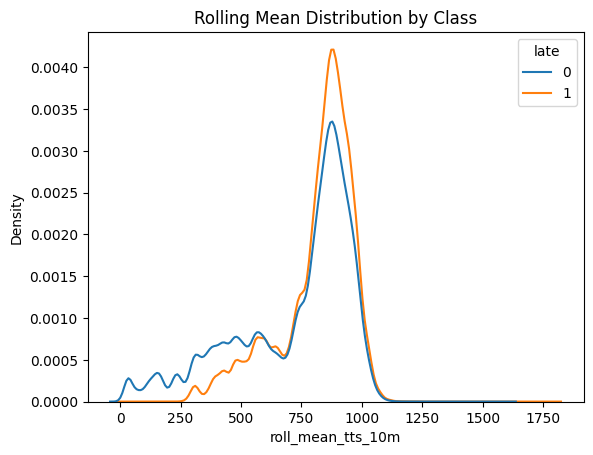

In [19]:
# Check if rolling mean differs for late vs non-late:
sns.kdeplot(data=df, x="roll_mean_tts_10m", hue="late", common_norm=False)
plt.title("Rolling Mean Distribution by Class")
plt.show()